In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Step 1: Load dataset
file_path = "/mnt/data/1_merged_stock_sentiment.csv"
merged_df = pd.read_csv(file_path)

# Step 2: Inspect and prepare data
print(merged_df.columns)
print(merged_df.head())

# Ensure 'date' is datetime type
merged_df['date'] = pd.to_datetime(merged_df['date'], errors='coerce')

# Step 3: Create target variable (predict next day's close)
merged_df['target'] = merged_df['close'].shift(-1)

# Drop last row with NaN target
merged_df = merged_df.dropna(subset=['target'])

# Step 4: Define features and target
feature_columns = [col for col in merged_df.columns if col not in ["date", "target"]]
X = merged_df[feature_columns].values
y = merged_df["target"].values

# Step 5: Normalize features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Step 6: Reshape for LSTM [samples, time steps, features]
X_scaled = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Step 7: Train/test split
split_index = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split_index], X_scaled[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [11]:
# Step 5: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [12]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [13]:
# Step 7: Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.4f}")

Test MSE: 4145.2401


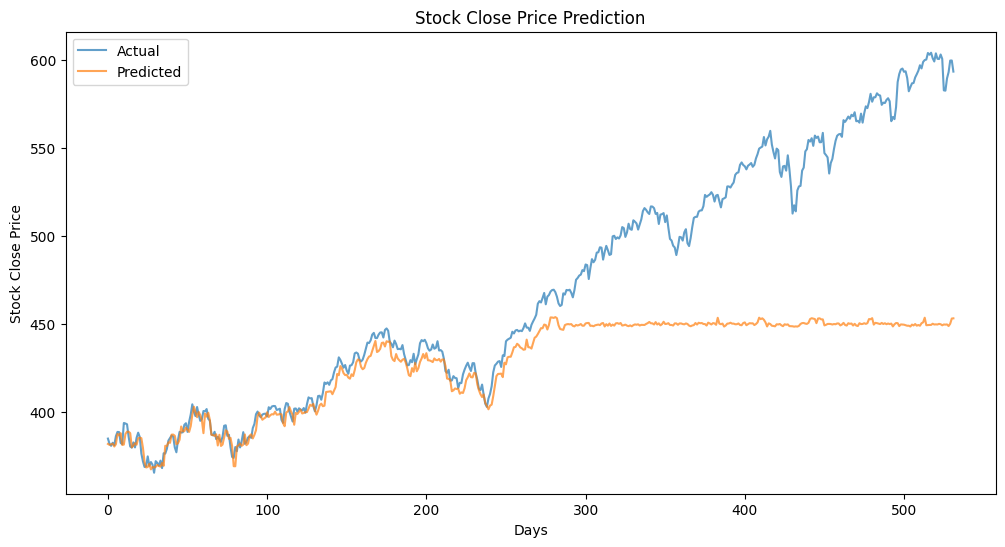

In [14]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual', alpha=0.7)
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.title("Stock Close Price Prediction")
plt.xlabel("Days")
plt.ylabel("Stock Close Price")
plt.legend()
plt.show()